# Section: Testing Migration Algorithms

# Foreward-Inverse Consistency Test
VelocityModelBuilder is a tkinter application generated using Caulde AI. On paper, making the annotations is fairly simple, but digitizing the velocity model reconstruction is tough without an interface. Any run-of-the-mill software (gprpy, for example) includes support for digitizing the vleocity model, but becasue our simulated results aren't in a format readable to these programs we have to come up with a workaround. I figure that because we've already established how to go about making these velocity models by hand, it is acceptable to give ourselves some grace and not spend 2-3 weeks coding an GUI that can be found out-of-the-box pretty much everywhere. The purpose of this project is not frontend software development, its to understand the science. the velocity model is made as follows:

1. Migrated image gets annotated with VelocityModelBuilder: the intermediate product that results is an image the same shape as the migrated image, but each annotation is assigned an index 0-n for the number of structures identified. For the case here, the bottom layer is index 1, the dihedral dipping reflector is 2, the upper point reflector is 3 AND so is the lower point reflector. Closing the app assigns 0 to the top layer (not annotated). I think this is a reasonable approach for the I-F test especially becasue in the field we'd do some tests to determined the facies permittivity before-hand. We can just say "we know what the velocities of the annotated things are supposed to be (at least for tests 1 and 2), so the only uncertainty in the annotation comes from where we put them." This is equivalent to assuming we did some hyperbola fitting process and it was perfectly accurate (or imperfectly accurate for test 3, velocity perturbation)
2. The 0-n value image is assigned a velocity according to the index value at each pixel. The mapping is described above. For the third test, instead of assigning the same velocities as in the true velocity model, we perturb them slightly (this is described in the paper) to simulate a bad hyperbola fitting procedure.
3. The reconstructed velocity model isn't the same shape as the true velocity model. We simply resize it to match the dimensions of the true velocity model using cv2.resize with the INTER_NEAREST interpolation --- this ensures that the resizing wont smooth out any edges, just move around pixels so that the resized image has len(np.unique(resized_reconstructed_velocity_model)) == len(np.unique(not_resized_reconstructed_velocity_model))
   - As Kirchhoff and F-K sometimes don't take the full velocity model as arguments, the migrated image, and velocity model reconstruction that results will obviously not be geometrically consistent with the true velocity model (you can see this yourself if you run one cycle of the test), the product of step 3 for these algorithms is a velocity model with the same horizontal shape as the true velocity model, but the vertical shape is clipped to the observable depth of the true velocity model. This shouldnt affect the Inverse-Foreward operation as the abc should prevent any ringing from the FDTD hitting the "bottom" of these reconstructed velocity models. One could easily just duplicate the last row using np.vstack() as well for Kirchhoff and F-K (it will just add a bunch of rows with permittivity = 5).
   - to sumarize:
     * True velocity model shape (80 rows, 100 columns)
     * Kirchhoff and F-K reconstructed model shape (~42 rows, 100 columns) --- just what FDTD "sees"
     * RTM reconstructed model shape (80 rows, 100 columns)

### Limitations of the test
The major limitation with this approach is that you NEED to assign exactly as many velocity contrasts in the reconstruction as in the true velocity model --- otherwise the mapping that occurs in step 2 doesn't work. For example, in the given true model, we have fields, epsilon = {0:4.0, 1:4.5, 2:5.0, 3:8}. The annotator needs to ensure that they annotate exactly 3 fields in VelocityModelBuilder (the fourth is automatically assigned). This could be remedied by doing a hyperbola fitting for each and every iteration, but for 3 tests, 11 perturbations per test, and 3 algorithms, fitting hyperbolae to 99 independent gpr section is wildly impractical. It's easier to just assume that we know there should be some number of "things" in the subsurface, we just don't know where they are or what their epsilon is. Additionally, the purpose of this test is to quatify MIGRATION uncertainty, hyperbola fitting would ocmplicate this by introducing additional sources of error (for example, how good the fit is, where the apex is placed, and how well we can (or C3 can) pick points on a hyperbolic template)

![How The Foreward-Inverse Consistency Test Works(Figure 6)](Quantifying_Migration_Uncertainty_Plan_1.png)

In [1]:
%gui tk

In [2]:
c0 = 3e8

In [2]:
import matplotlib.pyplot as plt
from bruges.filters.wavelets import ricker
import numpy as np
import scipy as scipy
import app as app
from app import VelocityModelBuilder
import cv2
import pandas as pd
import skimage

import sys
sys.path.append('../../..')

from SimulatingGPR import migration as mig
from SimulatingGPR import gprsim as gprsim

def dipping_reflector(p1, p2, step):
    '''
    Generate a dipping reflector. Assumes dx == 1. Function should be updated to accound for dx, dt this way we don't have a buch of wasted overlapping dipping reflectors. The result should not 
    change with gprsim though bc that checks at each trace for reflectors
    '''
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    slope = dy / dx

    # Build reflector line from p1 → p2
    line = []
    for x_offset in np.arange(0, dx + 1, step):
        x = p1[0] + x_offset
        y = p1[1] + slope * x_offset
        line.append((x, y))

    return line

def apply_perturbation_mask(perturbations, velocity_model):
    new_velocity = np.zeros_like(velocity_model)
    if len(perturbations) != len(np.unique(velocity_model)):
        raise Exception('Error')
        
    else:
        unique = np.unique(velocity_model)
        for i, val in enumerate(unique):
            new_velocity[np.where(velocity_model==unique[i])] = val+perturbations[i]     
            
    return new_velocity
    
def generate_velocity_perturbations(seed, trials):
    perturbations = []
    
    magnitude_delta = np.linspace(0.01,3,trials)
    for i in range(trials):
        np.random.seed(seed+i)
        perturbations.append([-1*magnitude_delta[i] if n<0 else magnitude_delta[i] for n in np.random.randn(4)])
        
    return perturbations

def assign_eps(image):
    hash = {}
    '''
    we outline from largest to smallest region
    expected: {0:4.0, 1.0:5.0, 2.0:4.5, 3.0:7.0}
    template:
    3nd highest count is 0   (idx 2)
    1st highest count is 1   (idx 0)
    2nd highest count is 2   (idx 1)
    4th highest count is 3   (idx 3)
    '''
    unique_vals, counts = np.unique(image, return_counts=True)
    hash[0.0] = unique_vals[np.argsort(counts)[::-1]][2]
    hash[1.0] = unique_vals[np.argsort(counts)[::-1]][0]
    hash[2.0] = unique_vals[np.argsort(counts)[::-1]][1]
    hash[3.0] = unique_vals[np.argsort(counts)[::-1]][3]
    return hash

def compute_consistency_metrics(true_velocity, predicted_velocity, true_radargram, synthetic_radargram):
    """
    Quantify how well the forward-inverse loop closed
    """
    # Velocity model error
    velocity_rmse = np.sqrt(np.mean((true_velocity - predicted_velocity)**2))
    velocity_correlation = np.corrcoef(true_velocity.flatten(), predicted_velocity.flatten())[0,1]
    
    # Radargram consistency
    radargram_rmse = np.sqrt(np.mean((true_radargram - synthetic_radargram)**2))
    radargram_correlation = np.corrcoef(true_radargram.flatten(), synthetic_radargram.flatten())[0,1]
    from skimage.metrics import structural_similarity as ssim
    # Structural similarity (SSIM)
    radargram_ssim = ssim(true_radargram, synthetic_radargram, data_range=synthetic_radargram.max())

    return {
        'velocity_rmse': velocity_rmse,
        'velocity_correlation': velocity_correlation,
        'radargram_rmse': radargram_rmse,
        'radargram_correlation': radargram_correlation,
        'radargram_ssim': radargram_ssim,
        'radargram_iou': iou_masks(true_radargram, synthetic_radargram)
    }

def iou_masks(mask1, mask2):
    mask1 = np.abs(mask1)
    mask1[np.where(mask1>pd.DataFrame({'nums': np.ravel(mask1)})['nums'].quantile(0.8))] = 1
    mask1[np.where(mask1<=pd.DataFrame({'nums': np.ravel(mask1)})['nums'].quantile(0.8))] = 0
    mask1 = ~mask1.astype(bool)

    mask2 = np.abs(mask2)
    mask2[np.where(mask2>pd.DataFrame({'nums': np.ravel(mask2)})['nums'].quantile(0.8))] = 1
    mask2[np.where(mask2<=pd.DataFrame({'nums': np.ravel(mask2)})['nums'].quantile(0.8))] = 0
    mask2 = ~mask2.astype(bool)
    
    # Intersection: logical AND of the two masks
    intersection = np.logical_and(mask1, mask2)
    
    # Union: logical OR of the two masks
    union = np.logical_or(mask1, mask2)
    
    # Sum the number of True pixels (treating True as 1)
    intersection_area = np.sum(intersection)
    union_area = np.sum(union)
    
    # Calculate IoU
    if union_area == 0:
        return 0.0 # Avoid division by zero if both masks are empty
    
    iou = intersection_area / union_area
    return iou

def depth_of_penetration(eps, dz, ns):
    c = 0.3
    layers = c/np.sqrt(eps.T[0])
    vels = np.unique(layers)
    pixels_per_vel = {} # perm: num pixels
    for vel in vels:
        pixels_per_vel[vel] = len(np.where(layers==vel)[0])
    ns_depth_visible_with_og_eps_model = 0
    for key in  pixels_per_vel.keys():
        ns_depth_visible_with_og_eps_model += (dz*pixels_per_vel[key]) / key # m * ns/m
    return int((len(layers) * (ns/ns_depth_visible_with_og_eps_model))/2)     


test_results = {}
'''
To run any test, just set two of the bellow to a constant and change the array name in the for loop
'''
dips = [60, 55, 50, 45, 40, 35, 30, 25, 20, 15, 10] # dip test perturbations
dip = 60

noises = np.linspace(3000, 1000000, 5)[::-1] # noise test perturbations
noise = np.inf

velocity_perturbations = generate_velocity_perturbations(1000, 11) # velocity-error test perturbations
velocity_perturbation = velocity_perturbations[0]

v_models = []
for dip in dips:

    '''
    Init velocity model
    '''
    print(f'Running test for dip={(5-20)/dip}')
    # Grid
    nx, nz = 80, 100
    dx = dz = 0.5 # 1 m grid
    
    # Permittivity model (background)
    eps = np.ones((nx, nz)) * 4  # ε_r = 9 (sand)


    eps[25:, :] = 4.5
    eps[30:, :] = 5.0
    
    
    # Add buried object
    eps[9:11, 20:22] = 7  # lower permittivity block
    for i in range(dip):
        for point in dipping_reflector((5,99), (25,(100-dip)+i), 0.25):
            eps[int(point[0]), int(point[1])] = 4.5
    
    for i in range(dip):
        for point in dipping_reflector((5,0), (25,(dip)-i), 0.25):
            eps[int(point[0]), int(point[1])] = 4.5
      
    eps[21:23, 80:82] = 7  # lower permittivity block

    '''
    Generate the Standard
    '''
    dt = 1e-9
    t_max = 300e-9
    f0 = 2.5e7
    np.random.seed(1001)
    radargram, x, t = gprsim.gpr_finite_difference_abc(
        eps.T,
        dx=dx,
        dz=dz,
        dt=dt,
        t_max=t_max,
        f0=f0,
        trace_spacing=2,
        SNR=noise
    )

    trials = {}
    '''
    Inverse "solution" 1. Kirchhoff
    '''
    data_demeaned = radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998

    px_per_ns = data_demeaned.shape[0]/(t_max*1e9)
    import SimulatingGPR.migration as mig
    import scipy as scipy
    
    eps_p = apply_perturbation_mask(velocity_perturbation, eps)
    
    Kmigrated, z = mig.Kirchhoff_fullfield(data_demeaned, eps_r=eps_p, Tlim=t_max, Nt=int(t_max/((1/px_per_ns)*1e-9)), t_samples=np.arange(0, t_max, ((1/px_per_ns)*1e-9)), x_positions=np.arange(0, 46, 1))
    # Kmigrated, z = mig.Kirchhoff(data_demeaned, eps_r=eps_p, Tlim=t_max, Nt=int(t_max/((1/px_per_ns)*1e-9)), t_samples=np.arange(0, t_max, ((1/px_per_ns)*1e-9)), x_positions=np.arange(0, 46, 1))
    
    migrated_image = np.abs(Kmigrated.T)
    
    extent = [0, 40, 50, 0]  # [x_min, x_max, z_max, z_min] in meters
    
    # Create and run the tool
    print("Starting velocity model builder...")
    print("Draw structures, assign IDs, then click 'Export Model'")
    
    builder = VelocityModelBuilder(migrated_image, extent=extent)
    velocity_mask, objects = builder.run()

    '''
    inverse-foreward 1. Kirchhoff
    '''
    v = assign_eps(eps_p)
    v_guess = cv2.resize(velocity_mask, eps[0:depth_of_penetration(eps, dz, t_max*1e9), :].shape[::-1],fx=0, fy=0, interpolation = cv2.INTER_NEAREST).astype('float32')
    for idx in np.unique(v_guess):
        v_guess[np.where(v_guess == idx)] = v[idx]
    v_models.append(v_guess)
    
    radargram_if, x, t = gprsim.gpr_finite_difference_abc(
            v_guess.T,
            dx=dx,
            dz=dz,
            dt=dt,
            t_max=t_max,
            f0=f0,
            trace_spacing=2,
            SNR=np.inf
        )
    trials['Kirchhoff'] = compute_consistency_metrics(eps[0:depth_of_penetration(eps, dz, t_max*1e9), :], v_guess, radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998, radargram_if[:, 2:-2] - np.mean(radargram_if[:, 2:-2], axis=1, keepdims=True)*0.998)

    '''
    Inverse "solution" 2. F-K
    '''
    data_demeaned = radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998
    px_per_ns = data_demeaned.shape[0]/(t_max*1e9)

    Dmig, tmig, xmig = mig.fkmig(data_demeaned, dt=dt, dx=dx, v=13e7/np.sqrt(np.mean(eps_p)), params=None)    
    migrated_image = np.abs(Dmig)
    
    # Create and run the tool
    print("Starting velocity model builder...")
    print("Draw structures, assign IDs, then click 'Export Model'")
    
    builder = VelocityModelBuilder(migrated_image, extent=extent)
    velocity_mask, objects = builder.run()

    '''
    inverse-foreward 2. F-K
    '''
    v = assign_eps(eps_p)
    v_guess = cv2.resize(velocity_mask, eps[0:depth_of_penetration(eps, dz, t_max*1e9), :].shape[::-1],fx=0, fy=0, interpolation = cv2.INTER_NEAREST).astype('float32')
    for idx in np.unique(v_guess):
        v_guess[np.where(v_guess == idx)] = v[idx]
    v_models.append(v_guess)
    
    radargram_if, x, t = gprsim.gpr_finite_difference_abc(
            v_guess.T,
            dx=dx,
            dz=dz,
            dt=dt,
            t_max=t_max,
            f0=f0,
            trace_spacing=2,
            SNR=np.inf
        )
    trials['F-K'] = compute_consistency_metrics(eps[0:depth_of_penetration(eps, dz, t_max*1e9), :], v_guess, radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998, radargram_if[:, 2:-2] - np.mean(radargram_if[:, 2:-2], axis=1, keepdims=True)*0.998)

    '''
    Inverse "solution" 3. RTM
    '''
    data_demeaned = radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998
    px_per_ns = data_demeaned.shape[0]/(t_max*1e9)
    
    velocity = c0 / np.sqrt(eps_p.T)
    w, _ = ricker(duration=1.5 / f0, dt=dt, f=f0)
    w /= np.max(np.abs(w))

    print(x, dx, dz, dt, velocity.shape, radargram.shape)
    migrated_image = mig.gpr_rtm(
        radargram=radargram,
        shot_positions=x,
        velocity_model=skimage.filters.gaussian(velocity, 9),
        dx=dx,
        dz=dz,
        dt=dt,
        source_wavelet=w
        )
    migrated_image = np.clip(migrated_image.T, a_min=-np.max(np.abs(migrated_image))*0.02, a_max=np.max(np.abs(migrated_image))*0.02)
    
    # Create and run the tool
    print("Starting velocity model builder...")
    print("Draw structures, assign IDs, then click 'Export Model'")
    
    builder = VelocityModelBuilder(migrated_image, extent=extent)
    velocity_mask, objects = builder.run()

    '''
    inverse-foreward 2. RTM
    '''
    v = assign_eps(eps_p)
    v_guess = cv2.resize(velocity_mask, eps.shape[::-1],fx=0, fy=0, interpolation = cv2.INTER_NEAREST).astype('float32')
    for idx in np.unique(v_guess):
        v_guess[np.where(v_guess == idx)] = v[idx]
    v_models.append(v_guess)
    
    radargram_if, x, t = gprsim.gpr_finite_difference_abc(
            v_guess.T,
            dx=dx,
            dz=dz,
            dt=dt,
            t_max=t_max,
            f0=f0,
            trace_spacing=2,
            SNR=np.inf
        )
    trials['RTM'] = compute_consistency_metrics(eps, v_guess, radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998, radargram_if[:, 2:-2] - np.mean(radargram_if[:, 2:-2], axis=1, keepdims=True)*0.998)

    
    test_results[dip] = trials


/Users/coltenrodriguez/anaconda3/lib/python3.10/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Running test for dip=-0.25
Points per wavelength: 9.1
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299


AttributeError: module 'SimulatingGPR.migration' has no attribute 'Kirchhoff_fullfield'

# Viaualizing the IoU metric

Points per wavelength: 9.1
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299
Points per wavelength: 9.1
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299
Points per wavelength: 9.1
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299


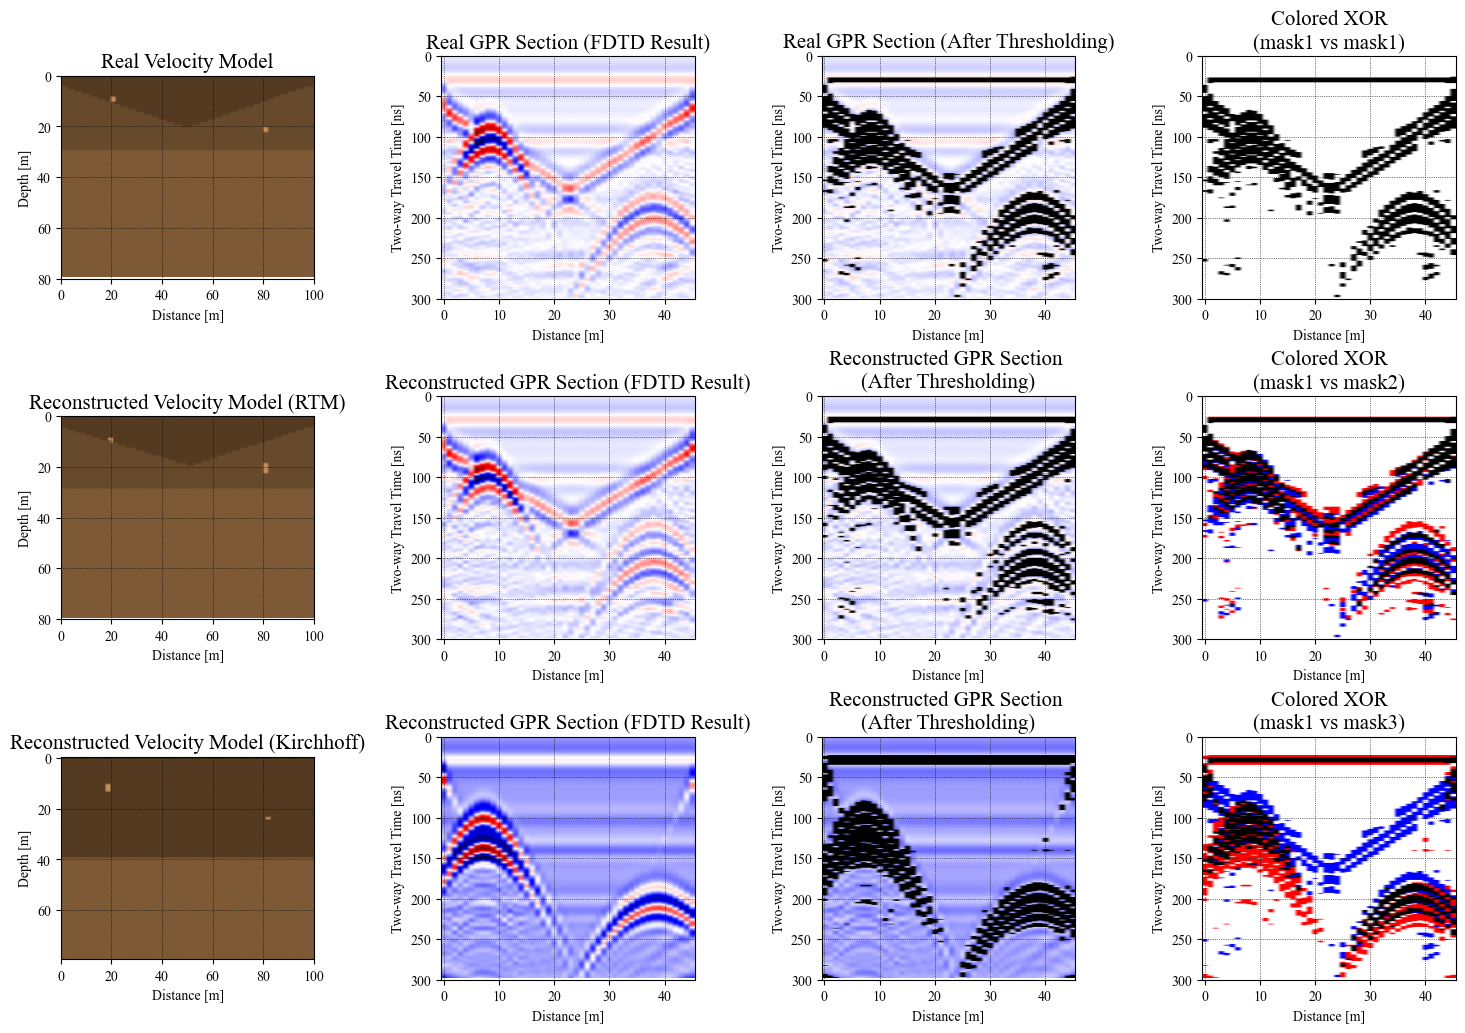

In [5]:
import json
import matplotlib

plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 10,
    'axes.titlesize': 15,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'black',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': True,
    'figure.subplot.wspace': 0.5
    ,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
})

filename = '/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/custom_cmap.json'

# Load the RGBA data from the JSON file
with open(filename, 'r') as f:
    cmap_data_list = json.load(f)

# Convert the list back to a numpy array
loaded_cmap_rgba = np.array(cmap_data_list)

# Recreate the colormap object
custom_cmap = matplotlib.colors.ListedColormap(loaded_cmap_rgba, name='recreated_custom_cmap')

fig, axs = plt.subplots(3,4, figsize=(18,12))
axs[0][0].imshow(eps, cmap=custom_cmap)
axs[0][0].set_title('Real Velocity Model')
axs[0][0].set_xlabel('Distance [m]')
axs[0][0].set_ylabel('Depth [m]')
axs[0][0].set_xlim(0,100.1), axs[0][0].set_ylim(80.1, 0)
def pad_rows(arr: np.ndarray, n: int) -> np.ndarray:
    return np.vstack([arr, np.tile(arr[-1], (n, 1))])

nx, nz = 80, 100
dx = dz = 0.5 # 1 m grid

# Permittivity model (background)
eps2 = np.ones((nx, nz)) * 4  # ε_r = 9 (sand)


eps2[23:, :] = 4.5
eps2[29:, :] = 5.0


# Add buried object
eps2[9:11, 19:21] = 7  # lower permittivity block
for i in range(dip):
    for point in dipping_reflector((5,99), (24,(100-dip)+i), 0.25):
        eps2[int(point[0]), int(point[1])] = 4.5

for i in range(dip):
    for point in dipping_reflector((5,0), (23,(dip)-i), 0.25):
        eps2[int(point[0]), int(point[1])] = 4.5
  
eps2[19:23, 80:82] = 7  # lower permittivity block

axs[1][0].imshow(eps2, cmap=custom_cmap)
axs[1][0].set_title('Reconstructed Velocity Model (RTM)')
axs[1][0].set_xlabel('Distance [m]')
axs[1][0].set_ylabel('Depth [m]')
axs[1][0].set_xlim(0,100.1), axs[1][0].set_ylim(80.1, 0)

nx, nz = 80, 100
dx = dz = 0.5 # 1 m grid

# Permittivity model (background)
eps3 = np.ones((nx, nz)) * 4  # ε_r = 9 (sand)
eps3[40:, :] = 5.0
eps3[11:14, 18:20] = 7
eps3[24:25, 81:83] = 7  # lower permittivity block

axs[2][0].imshow(eps3, cmap=custom_cmap)
axs[2][0].set_title('Reconstructed Velocity Model (Kirchhoff)')
axs[2][0].set_xlabel('Distance [m]')
axs[2][0].set_ylabel('Depth [m]')
axs[2][0].set_xlim(0,100.1), axs[1][0].set_ylim(80.1, 0)

radargram, x, t = gprsim.gpr_finite_difference_abc(
    eps.T,
    dx=dx,
    dz=dz,
    dt=dt,
    t_max=t_max,
    f0=f0,
    trace_spacing=2,
    SNR=np.inf
)
axs[0][1].imshow(radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998, aspect='auto', cmap='seismic')
axs[0][1].set_title('Real GPR Section (FDTD Result)')
axs[0][1].set_xlabel('Distance [m]')
axs[0][1].set_ylabel('Two-way Travel Time [ns]')
axs[0][1].set_ylim(300.1, 0)

radargram_if, x, t = gprsim.gpr_finite_difference_abc(
    eps2.T,
    dx=dx,
    dz=dz,
    dt=dt,
    t_max=t_max,
    f0=f0,
    trace_spacing=2,
    SNR=np.inf
)
axs[1][1].imshow(radargram_if[:, 2:-2] - np.mean(radargram_if[:, 2:-2], axis=1, keepdims=True)*0.998, aspect='auto', cmap='seismic')
axs[1][1].set_title('Reconstructed GPR Section (FDTD Result)')
axs[1][1].set_xlabel('Distance [m]')
axs[1][1].set_ylabel('Two-way Travel Time [ns]')
axs[1][1].set_ylim(300.1, 0)

radargram_if1, x, t = gprsim.gpr_finite_difference_abc(
    eps3.T,
    dx=dx,
    dz=dz,
    dt=dt,
    t_max=t_max,
    f0=f0,
    trace_spacing=2,
    SNR=np.inf
)
axs[2][1].imshow(radargram_if1[:, 2:-2] - np.mean(radargram_if1[:, 2:-2], axis=1, keepdims=True)*0.998, aspect='auto', cmap='seismic')
axs[2][1].set_title('Reconstructed GPR Section (FDTD Result)')
axs[2][1].set_xlabel('Distance [m]')
axs[2][1].set_ylabel('Two-way Travel Time [ns]')
axs[2][1].set_ylim(300.1, 0)



# # #compute_consistency_metrics(eps[0:depth_of_penetration(eps, dz, t_max*1e9), :], v_guess, radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998, radargram_if[:, 2:-2] - np.mean(radargram_if[:, 2:-2], axis=1, keepdims=True)*0.998)

damped_radargram = radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998
mask1 = np.abs(damped_radargram)
mask1[np.where(mask1>pd.DataFrame({'nums': np.ravel(mask1)})['nums'].quantile(0.8))] = 1
mask1[np.where(mask1<=pd.DataFrame({'nums': np.ravel(mask1)})['nums'].quantile(0.8))] = 0
mask1 = ~mask1.astype(bool)

damped_radargram_if = (radargram_if[:, 2:-2] - np.mean(radargram_if[:, 2:-2], axis=1, keepdims=True)*0.998)
mask2 = np.abs(damped_radargram_if)
mask2[np.where(mask2>pd.DataFrame({'nums': np.ravel(mask2)})['nums'].quantile(0.8))] = 1
mask2[np.where(mask2<=pd.DataFrame({'nums': np.ravel(mask2)})['nums'].quantile(0.8))] = 0
mask2 = ~mask2.astype(bool)

damped_radargram_if1 = (radargram_if1[:, 2:-2] - np.mean(radargram_if1[:, 2:-2], axis=1, keepdims=True)*0.998)
mask3 = np.abs(damped_radargram_if1)
mask3[np.where(mask3>pd.DataFrame({'nums': np.ravel(mask3)})['nums'].quantile(0.8))] = 1
mask3[np.where(mask3<=pd.DataFrame({'nums': np.ravel(mask3)})['nums'].quantile(0.8))] = 0
mask3 = ~mask3.astype(bool)

cmap = plt.cm.seismic
cmap.set_bad('black')

damped_radargram_masked =  np.ma.masked_where(~mask1, damped_radargram)
axs[0][2].imshow(damped_radargram_masked, aspect='auto', cmap=cmap, vmin=damped_radargram.min(), vmax=damped_radargram.max())
axs[0][2].set_title('Real GPR Section (After Thresholding)')
axs[0][2].set_xlabel('Distance [m]')
axs[0][2].set_ylabel('Two-way Travel Time [ns]')
axs[0][2].set_ylim(300.1, 0)

damped_radargram_if_masked =  np.ma.masked_where(~mask2, damped_radargram_if)
axs[1][2].imshow(damped_radargram_if_masked, aspect='auto', cmap=cmap, vmin=damped_radargram_if.min(), vmax=damped_radargram_if.max())
axs[1][2].set_title('Reconstructed GPR Section \n(After Thresholding)')
axs[1][2].set_xlabel('Distance [m]')
axs[1][2].set_ylabel('Two-way Travel Time [ns]')
axs[1][2].set_ylim(300.1, 0)

damped_radargram_if1_masked =  np.ma.masked_where(~mask3, damped_radargram_if1)
axs[2][2].imshow(damped_radargram_if1_masked, aspect='auto', cmap=cmap, vmin=damped_radargram_if1.min(), vmax=damped_radargram_if1.max())
axs[2][2].set_title('Reconstructed GPR Section \n(After Thresholding)')
axs[2][2].set_xlabel('Distance [m]')
axs[2][2].set_ylabel('Two-way Travel Time [ns]')
axs[2][2].set_ylim(300.1, 0)


def plot_colored_xor(ax, mask_ref, mask_comp, title):
    rgb = np.zeros((*mask_ref.shape, 3), dtype=np.float32)
    
    # Red channel: pixels only in reference mask
    only_ref = mask_ref & ~mask_comp
    rgb[only_ref] = [1, 0, 0]
    
    # Blue channel: pixels only in comparison mask
    only_comp = mask_comp & ~mask_ref
    rgb[only_comp] = [0, 0, 1]
    
    # White: agreement where both are True (AND)
    agreement = mask_ref & mask_comp
    rgb[agreement] = [1, 1, 1]
    
    ax.imshow(rgb, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Distance [m]')
    ax.set_ylabel('Two-way Travel Time [ns]')
    ax.set_ylim(300.1, 0)

# Row 0: mask1 vs mask1 (sanity check — should be all white/black, no red/blue)
plot_colored_xor(axs[0][3], mask1, mask1, 'Colored XOR\n(mask1 vs mask1)')

# Row 1: mask1 vs mask2
plot_colored_xor(axs[1][3], mask1, mask2, 'Colored XOR\n(mask1 vs mask2)')

# Row 2: mask1 vs mask3
plot_colored_xor(axs[2][3], mask1, mask3, 'Colored XOR\n(mask1 vs mask3)')

## Data from my tests is given in the below cell

In [3]:
tests = {60: {'Kirchhoff': {'velocity_rmse': 0.34082038757293537,
   'velocity_correlation': 0.6950825910813097,
   'radargram_rmse': 0.012139459527391112,
   'radargram_correlation': 0.25931068763275655,
   'radargram_ssim': 0.23288035872518476,
   'radargram_iou': 0.73289235372864},
  'F-K': {'velocity_rmse': 0.3288004806832876,
   'velocity_correlation': 0.7178014092856833,
   'radargram_rmse': 0.011645612074193455,
   'radargram_correlation': 0.16278862020385604,
   'radargram_ssim': 0.21541185443233066,
   'radargram_iou': 0.7233925914323753},
  'RTM': {'velocity_rmse': 0.28820565573909196,
   'velocity_correlation': 0.7914585653040578,
   'radargram_rmse': 0.016228415223839356,
   'radargram_correlation': -0.1196300080971659,
   'radargram_ssim': 0.23602232434851378,
   'radargram_iou': 0.71801077367476}},
 55: {'Kirchhoff': {'velocity_rmse': 0.3118590988907901,
   'velocity_correlation': 0.7428501463452388,
   'radargram_rmse': 0.011555200699248954,
   'radargram_correlation': 0.1863255081709896,
   'radargram_ssim': 0.214599280801531,
   'radargram_iou': 0.7305516265912305},
  'F-K': {'velocity_rmse': 0.31977507338905514,
   'velocity_correlation': 0.7302453047986008,
   'radargram_rmse': 0.011469567645678727,
   'radargram_correlation': 0.17684121657452384,
   'radargram_ssim': 0.2111323341368482,
   'radargram_iou': 0.7265104615625735},
  'RTM': {'velocity_rmse': 0.25653947064730603,
   'velocity_correlation': 0.8282960751143994,
   'radargram_rmse': 0.014480935040442183,
   'radargram_correlation': -0.13318048640463492,
   'radargram_ssim': 0.2326561000178874,
   'radargram_iou': 0.7433256753545117}},
 50: {'Kirchhoff': {'velocity_rmse': 0.32656751440309345,
   'velocity_correlation': 0.72453405755237,
   'radargram_rmse': 0.011217664089454592,
   'radargram_correlation': 0.22252304575106327,
   'radargram_ssim': 0.22962897405824026,
   'radargram_iou': 0.7365845959595959},
  'F-K': {'velocity_rmse': 0.34570535882735637,
   'velocity_correlation': 0.6878701967994013,
   'radargram_rmse': 0.013022930931401985,
   'radargram_correlation': 0.11800038623519672,
   'radargram_ssim': 0.23355901863972525,
   'radargram_iou': 0.73384809328711},
  'RTM': {'velocity_rmse': 0.26786190471957744,
   'velocity_correlation': 0.8183823111808239,
   'radargram_rmse': 0.01563008366080259,
   'radargram_correlation': -0.11023780311794958,
   'radargram_ssim': 0.22763067563661368,
   'radargram_iou': 0.7277223836068147}},
 45: {'Kirchhoff': {'velocity_rmse': 0.3253515921838794,
   'velocity_correlation': 0.7269944105988875,
   'radargram_rmse': 0.011369887457102714,
   'radargram_correlation': 0.22662414065262249,
   'radargram_ssim': 0.2535278189914919,
   'radargram_iou': 0.744569525923577},
  'F-K': {'velocity_rmse': 0.3640054944640259,
   'velocity_correlation': 0.6604930966046212,
   'radargram_rmse': 0.011850891759193117,
   'radargram_correlation': 0.20028596328830436,
   'radargram_ssim': 0.24803366418180753,
   'radargram_iou': 0.73289235372864},
  'RTM': {'velocity_rmse': 0.24379807218269794,
   'velocity_correlation': 0.8489511069733591,
   'radargram_rmse': 0.014832423961471627,
   'radargram_correlation': -0.0996802030367721,
   'radargram_ssim': 0.21984684453039763,
   'radargram_iou': 0.7411625148279952}},
 40: {'Kirchhoff': {'velocity_rmse': 0.34956418859948957,
   'velocity_correlation': 0.686147026843087,
   'radargram_rmse': 0.012130909306163049,
   'radargram_correlation': 0.1644555299099181,
   'radargram_ssim': 0.223764592119633,
   'radargram_iou': 0.7458151527171757},
  'F-K': {'velocity_rmse': 0.33349589531975043,
   'velocity_correlation': 0.7163569544128724,
   'radargram_rmse': 0.010666856645408165,
   'radargram_correlation': 0.22433161579136313,
   'radargram_ssim': 0.25277030078480145,
   'radargram_iou': 0.7434658640899731},
  'RTM': {'velocity_rmse': 0.2441823089414956,
   'velocity_correlation': 0.8517619636530399,
   'radargram_rmse': 0.01181146645237968,
   'radargram_correlation': 0.22533820557675624,
   'radargram_ssim': 0.24964502283567394,
   'radargram_iou': 0.7625951141369643}},
 35: {'Kirchhoff': {'velocity_rmse': 0.33695190363886307,
   'velocity_correlation': 0.7145620776546376,
   'radargram_rmse': 0.010896819701427205,
   'radargram_correlation': 0.21504537344028277,
   'radargram_ssim': 0.2625507673406236,
   'radargram_iou': 0.7527052832590706},
  'F-K': {'velocity_rmse': 0.3226226369206887,
   'velocity_correlation': 0.7335203728638056,
   'radargram_rmse': 0.010595400004314687,
   'radargram_correlation': 0.22009050994279297,
   'radargram_ssim': 0.26099668336377235,
   'radargram_iou': 0.75},
  'RTM': {'velocity_rmse': 0.2548283736164401,
   'velocity_correlation': 0.8389774316485302,
   'radargram_rmse': 0.01455853184305115,
   'radargram_correlation': -0.13705741861294954,
   'radargram_ssim': 0.21865099149909467,
   'radargram_iou': 0.7518102968091032}},
 30: {'Kirchhoff': {'velocity_rmse': 0.3447339023284976,
   'velocity_correlation': 0.7061374551619977,
   'radargram_rmse': 0.010502111542612524,
   'radargram_correlation': 0.1999092509549576,
   'radargram_ssim': 0.2423524251039511,
   'radargram_iou': 0.7620951619352259},
  'F-K': {'velocity_rmse': 0.3254452859488695,
   'velocity_correlation': 0.7296731486448497,
   'radargram_rmse': 0.010685425615980952,
   'radargram_correlation': 0.1968102154554117,
   'radargram_ssim': 0.24668453419326672,
   'radargram_iou': 0.7612500999120774},
  'RTM': {'velocity_rmse': 0.2285825890132492,
   'velocity_correlation': 0.8716851416559062,
   'radargram_rmse': 0.012592575096999958,
   'radargram_correlation': 0.12869529020221762,
   'radargram_ssim': 0.23664549141292196,
   'radargram_iou': 0.7834884662080129}},
 25: {'Kirchhoff': {'velocity_rmse': 0.3370423726708702,
   'velocity_correlation': 0.7204777005676586,
   'radargram_rmse': 0.011041615037088151,
   'radargram_correlation': 0.28187819050986646,
   'radargram_ssim': 0.27228893254818565,
   'radargram_iou': 0.7582294662831576},
  'F-K': {'velocity_rmse': 0.3510437398915884,
   'velocity_correlation': 0.704568409214944,
   'radargram_rmse': 0.010433885346043571,
   'radargram_correlation': 0.19128888422186854,
   'radargram_ssim': 0.2478098029593635,
   'radargram_iou': 0.7608382658774596},
  'RTM': {'velocity_rmse': 0.25273503912200224,
   'velocity_correlation': 0.8436091804906894,
   'radargram_rmse': 0.014854140895948987,
   'radargram_correlation': -0.12517037443529377,
   'radargram_ssim': 0.23531413875166207,
   'radargram_iou': 0.7564051400750259}},
 20: {'Kirchhoff': {'velocity_rmse': 0.34816592624081116,
   'velocity_correlation': 0.7092386373807599,
   'radargram_rmse': 0.01037951607691958,
   'radargram_correlation': 0.15786729927193016,
   'radargram_ssim': 0.23585088854918088,
   'radargram_iou': 0.7763965127542783},
  'F-K': {'velocity_rmse': 0.3778953268416804,
   'velocity_correlation': 0.6621555203436115,
   'radargram_rmse': 0.010591282097050908,
   'radargram_correlation': 0.18774192659312686,
   'radargram_ssim': 0.21580626824952526,
   'radargram_iou': 0.764290868275475},
  'RTM': {'velocity_rmse': 0.24456594202791196,
   'velocity_correlation': 0.855106850776775,
   'radargram_rmse': 0.015224435622896292,
   'radargram_correlation': -0.2804674790003424,
   'radargram_ssim': 0.2195362209176686,
   'radargram_iou': 0.7711066398390342}},
 15: {'Kirchhoff': {'velocity_rmse': 0.34641016151377546,
   'velocity_correlation': 0.6977861513260744,
   'radargram_rmse': 0.011596739112889519,
   'radargram_correlation': 0.034137080678910595,
   'radargram_ssim': 0.2054147324017444,
   'radargram_iou': 0.7652815658591369},
  'F-K': {'velocity_rmse': 0.42812694720938704,
   'velocity_correlation': 0.6101988323902293,
   'radargram_rmse': 0.011384511845474864,
   'radargram_correlation': 0.013017389735259694,
   'radargram_ssim': 0.21857539520791727,
   'radargram_iou': 0.7607617218755001},
  'RTM': {'velocity_rmse': 0.24399026619928918,
   'velocity_correlation': 0.8567738164740257,
   'radargram_rmse': 0.014529133143659258,
   'radargram_correlation': -0.10458307815501232,
   'radargram_ssim': 0.25288821181932947,
   'radargram_iou': 0.7766927608748285}},
 10: {'Kirchhoff': {'velocity_rmse': 0.44034354659105684,
   'velocity_correlation': 0.5921693075566101,
   'radargram_rmse': 0.009930116260090728,
   'radargram_correlation': 0.25679246170707,
   'radargram_ssim': 0.29355830632924973,
   'radargram_iou': 0.7614664211958697},
  'F-K': {'velocity_rmse': 0.3208221146808503,
   'velocity_correlation': 0.7571481740662344,
   'radargram_rmse': 0.01016537334699465,
   'radargram_correlation': 0.17519823028253584,
   'radargram_ssim': 0.2338585208878078,
   'radargram_iou': 0.7590890930882941},
  'RTM': {'velocity_rmse': 0.23351927115336757,
   'velocity_correlation': 0.8695212141042684,
   'radargram_rmse': 0.011974293253389725,
   'radargram_correlation': 0.1588486486507112,
   'radargram_ssim': 0.2664723547801109,
    'radargram_iou': 0.7862012987012987}}}

tests_exp1_dip = {60: {'Kirchhoff': {'velocity_rmse': 0.324788861998143,
   'velocity_correlation': 0.7239532772024893,
   'radargram_rmse': 0.01140683749612229,
   'radargram_correlation': 0.15387023427148275,
   'radargram_ssim': 0.22013056840486478,
   'radargram_iou': 0.7160012476606363},
  'F-K': {'velocity_rmse': 0.3035360709066773,
   'velocity_correlation': 0.7566067278406408,
   'radargram_rmse': 0.012580707735227799,
   'radargram_correlation': 0.03492953301453622,
   'radargram_ssim': 0.22335660480535618,
   'radargram_iou': 0.7273155416012559},
  'RTM': {'velocity_rmse': 0.1755348968154196,
   'velocity_correlation': 0.9067593469689664,
   'radargram_rmse': 0.012617100117423598,
   'radargram_correlation': 0.27449865032113435,
   'radargram_ssim': 0.29159634059099526,
   'radargram_iou': 0.8040662403672734}},
 55: {'Kirchhoff': {'velocity_rmse': 0.3325804505643123,
   'velocity_correlation': 0.7124394478694328,
   'radargram_rmse': 0.012558613185038243,
   'radargram_correlation': 0.1212314467734657,
   'radargram_ssim': 0.22085061949565454,
   'radargram_iou': 0.7198905822586948},
  'F-K': {'velocity_rmse': 0.3459698280937508,
   'velocity_correlation': 0.6861033470030534,
   'radargram_rmse': 0.01352146492853651,
   'radargram_correlation': 0.0708992693035886,
   'radargram_ssim': 0.22787109616881376,
   'radargram_iou': 0.7408432877145795},
  'RTM': {'velocity_rmse': 0.17056890103415687,
   'velocity_correlation': 0.9129080967761846,
   'radargram_rmse': 0.014668094864706382,
   'radargram_correlation': -0.10598704735232084,
   'radargram_ssim': 0.3050914751305491,
   'radargram_iou': 0.7739621120515922}},
 50: {'Kirchhoff': {'velocity_rmse': 0.32053689715698,
   'velocity_correlation': 0.7403751769156557,
   'radargram_rmse': 0.012084238606869437,
   'radargram_correlation': 0.18283682507928023,
   'radargram_ssim': 0.2465227705660912,
   'radargram_iou': 0.7330288234367617},
  'F-K': {'velocity_rmse': 0.3645913181471724,
   'velocity_correlation': 0.6602742271124783,
   'radargram_rmse': 0.014236466199832064,
   'radargram_correlation': 0.0796777259516857,
   'radargram_ssim': 0.1935572186889412,
   'radargram_iou': 0.713996417166446},
  'RTM': {'velocity_rmse': 0.17615689029952816,
   'velocity_correlation': 0.9112865416133253,
   'radargram_rmse': 0.010386176970979636,
   'radargram_correlation': 0.4823118115795928,
   'radargram_ssim': 0.3953187698080069,
   'radargram_iou': 0.7962615296710472}},
 45: {'Kirchhoff': {'velocity_rmse': 0.3209171308578724,
   'velocity_correlation': 0.7395400976766083,
   'radargram_rmse': 0.011738701037392956,
   'radargram_correlation': 0.20553392339164137,
   'radargram_ssim': 0.24444694494759162,
   'radargram_iou': 0.7387800252844501},
  'F-K': {'velocity_rmse': 0.3415352711850046,
   'velocity_correlation': 0.7035827424282906,
   'radargram_rmse': 0.013654432267791223,
   'radargram_correlation': 0.0750400788370361,
   'radargram_ssim': 0.20137532226945729,
   'radargram_iou': 0.7349416587827183},
  'RTM': {'velocity_rmse': 0.1816590212458495,
   'velocity_correlation': 0.9079117236609504,
   'radargram_rmse': 0.0147085724810149,
   'radargram_correlation': -0.034419002325091826,
   'radargram_ssim': 0.38527248181305707,
   'radargram_iou': 0.7931877444589309}},
 40: {'Kirchhoff': {'velocity_rmse': 0.34135669063884255,
   'velocity_correlation': 0.7149434933401093,
   'radargram_rmse': 0.011963312800322404,
   'radargram_correlation': 0.037924227704430956,
   'radargram_ssim': 0.2177178713127331,
   'radargram_iou': 0.7478951548848293},
  'F-K': {'velocity_rmse': 0.33947592320962083,
   'velocity_correlation': 0.72855514385765,
   'radargram_rmse': 0.013792860009530984,
   'radargram_correlation': 0.05622774321142683,
   'radargram_ssim': 0.1994774373505102,
   'radargram_iou': 0.7372700718402148},
  'RTM': {'velocity_rmse': 0.18140079933671735,
   'velocity_correlation': 0.9103096925427321,
   'radargram_rmse': 0.012654262193589495,
   'radargram_correlation': 0.1241999442459016,
   'radargram_ssim': 0.3527821492441589,
   'radargram_iou': 0.7862012987012987}},
 35: {'Kirchhoff': {'velocity_rmse': 0.32712718493263626,
   'velocity_correlation': 0.7377362055617125,
   'radargram_rmse': 0.011646822270044497,
   'radargram_correlation': 0.07653621232752042,
   'radargram_ssim': 0.241190317597605,
   'radargram_iou': 0.7634193238263098},
  'F-K': {'velocity_rmse': 0.32740666143378866,
   'velocity_correlation': 0.7383019936981758,
   'radargram_rmse': 0.012995689986293983,
   'radargram_correlation': -0.00376514799605664,
   'radargram_ssim': 0.19874056116632036,
   'radargram_iou': 0.7480146124523507},
  'RTM': {'velocity_rmse': 0.18599395151455866,
   'velocity_correlation': 0.9096037295793287,
   'radargram_rmse': 0.013218532015610554,
   'radargram_correlation': 0.03620038783064963,
   'radargram_ssim': 0.3678678137651049,
   'radargram_iou': 0.8089250493096647}},
 30: {'Kirchhoff': {'velocity_rmse': 0.32422515513067796,
   'velocity_correlation': 0.7494877796719535,
   'radargram_rmse': 0.01116523329830204,
   'radargram_correlation': 0.08747677435068783,
   'radargram_ssim': 0.21369501413191827,
   'radargram_iou': 0.7516516755552017},
  'F-K': {'velocity_rmse': 0.3674234614174767,
   'velocity_correlation': 0.685945927302707,
   'radargram_rmse': 0.011846187924808368,
   'radargram_correlation': 0.06335713401760908,
   'radargram_ssim': 0.229508489078022,
   'radargram_iou': 0.7562649640861931},
  'RTM': {'velocity_rmse': 0.17993054215446583,
   'velocity_correlation': 0.9155665612744943,
   'radargram_rmse': 0.013901898694697969,
   'radargram_correlation': -0.17599926196415763,
   'radargram_ssim': 0.37103893278388705,
   'radargram_iou': 0.8092575844775137}},
 25: {'Kirchhoff': {'velocity_rmse': 0.3152621827978088,
   'velocity_correlation': 0.775614107622248,
   'radargram_rmse': 0.010818903091012008,
   'radargram_correlation': 0.24736139617282957,
   'radargram_ssim': 0.2823023043096404,
   'radargram_iou': 0.7840291852452371},
  'F-K': {'velocity_rmse': 0.362158165150761,
   'velocity_correlation': 0.6887240783319181,
   'radargram_rmse': 0.010696211730081858,
   'radargram_correlation': 0.02621903617829966,
   'radargram_ssim': 0.21815721450863457,
   'radargram_iou': 0.752488651748029},
  'RTM': {'velocity_rmse': 0.18328597873268976,
   'velocity_correlation': 0.9179165901550579,
   'radargram_rmse': 0.01149042464784963,
   'radargram_correlation': 0.2458516699229734,
   'radargram_ssim': 0.3016791548655487,
   'radargram_iou': 0.7484506594628952}},
 20: {'Kirchhoff': {'velocity_rmse': 0.3122498999199199,
   'velocity_correlation': 0.7810970900667565,
   'radargram_rmse': 0.0122190346754609,
   'radargram_correlation': 0.043126033083108375,
   'radargram_ssim': 0.22243001157639042,
   'radargram_iou': 0.7805647706125091},
  'F-K': {'velocity_rmse': 0.3541565039192316,
   'velocity_correlation': 0.7086743556010598,
   'radargram_rmse': 0.01009951642744665,
   'radargram_correlation': 0.17560661710524095,
   'radargram_ssim': 0.2170889946714208,
   'radargram_iou': 0.7437400950871632},
  'RTM': {'velocity_rmse': 0.19006577808748212,
   'velocity_correlation': 0.9106608851618321,
   'radargram_rmse': 0.010396833685868375,
   'radargram_correlation': 0.44073670325642494,
   'radargram_ssim': 0.4671595215783965,
   'radargram_iou': 0.8061391989494419}},
 15: {'Kirchhoff': {'velocity_rmse': 0.30742835770623245,
   'velocity_correlation': 0.7844567236633705,
   'radargram_rmse': 0.012018199916683065,
   'radargram_correlation': 0.04134475295478064,
   'radargram_ssim': 0.21930215954227425,
   'radargram_iou': 0.7833063209076175},
  'F-K': {'velocity_rmse': 0.4072513456534986,
   'velocity_correlation': 0.6571477358014177,
   'radargram_rmse': 0.011307322023582136,
   'radargram_correlation': 0.07469171316015837,
   'radargram_ssim': 0.2054434327379198,
   'radargram_iou': 0.7437400950871632},
  'RTM': {'velocity_rmse': 0.20046820196729456,
   'velocity_correlation': 0.8999911523490708,
   'radargram_rmse': 0.011358778604370926,
   'radargram_correlation': 0.30995588899018184,
   'radargram_ssim': 0.32588331028645967,
   'radargram_iou': 0.8167422680412371}},
 10: {'Kirchhoff': {'velocity_rmse': 0.27629958996465076,
   'velocity_correlation': 0.8332664263046047,
   'radargram_rmse': 0.010134404464946603,
   'radargram_correlation': 0.1622704985345106,
   'radargram_ssim': 0.28327572084161484,
   'radargram_iou': 0.7363729589019484},
  'F-K': {'velocity_rmse': 0.5684810741856909,
   'velocity_correlation': 0.4435344916444431,
   'radargram_rmse': 0.010023884881415755,
   'radargram_correlation': 0.08062551032613335,
   'radargram_ssim': 0.2287852522603963,
   'radargram_iou': 0.7318013693239946},
  'RTM': {'velocity_rmse': 0.2006240264773888,
   'velocity_correlation': 0.9019061429649124,
   'radargram_rmse': 0.012816540239196164,
   'radargram_correlation': 0.10208953950174558,
   'radargram_ssim': 0.29881104495622923,
   'radargram_iou': 0.8183771277474797}}}

tests_exp2_noise = {10000000.0: {'Kirchhoff': {'velocity_rmse': 0.3037368887062874,
   'velocity_correlation': 0.7389850616934719,
   'radargram_rmse': 0.012606661316885159,
   'radargram_correlation': -0.059961918153600725,
   'radargram_ssim': 0.21246337992386907,
   'radargram_iou': 0.746569366225113},
  'F-K': {'velocity_rmse': 0.2959070387972481,
   'velocity_correlation': 0.751395226724801,
   'radargram_rmse': 0.012085254517870027,
   'radargram_correlation': -0.04574790178633758,
   'radargram_ssim': 0.20524260509137968,
   'radargram_iou': 0.7458151527171757},
  'RTM': {'velocity_rmse': 0.14884975646604195,
   'velocity_correlation': 0.9309734055152707,
   'radargram_rmse': 0.0067303708325685595,
   'radargram_correlation': 0.7587384884547733,
   'radargram_ssim': 0.5951046087432711,
   'radargram_iou': 0.8511103633916555}},
 9000500.0: {'Kirchhoff': {'velocity_rmse': 0.28680323840740646,
   'velocity_correlation': 0.7639394833676495,
   'radargram_rmse': 0.01060913055589385,
   'radargram_correlation': 0.09096102444883276,
   'radargram_ssim': 0.20166330601706503,
   'radargram_iou': 0.7455381930673436},
  'F-K': {'velocity_rmse': 0.292487231324386,
   'velocity_correlation': 0.7544411092974564,
   'radargram_rmse': 0.01220885414421572,
   'radargram_correlation': -0.06935256914341886,
   'radargram_ssim': 0.2145645831929104,
   'radargram_iou': 0.752488651748029},
  'RTM': {'velocity_rmse': 0.1477963125385745,
   'velocity_correlation': 0.9320388582155619,
   'radargram_rmse': 0.006340209987985725,
   'radargram_correlation': 0.8047672439918389,
   'radargram_ssim': 0.6326333649724348,
   'radargram_iou': 0.8583009626752238}},
 8001000.0: {'Kirchhoff': {'velocity_rmse': 0.2907098125656429,
   'velocity_correlation': 0.7560563201478679,
   'radargram_rmse': 0.012462879174427156,
   'radargram_correlation': -0.0847289818309024,
   'radargram_ssim': 0.21525398800060938,
   'radargram_iou': 0.7614664211958697},
  'F-K': {'velocity_rmse': 0.2933199368707379,
   'velocity_correlation': 0.7536919414727302,
   'radargram_rmse': 0.012290975307627454,
   'radargram_correlation': -0.0023110254786117166,
   'radargram_ssim': 0.19890457809082268,
   'radargram_iou': 0.7512334871876493},
  'RTM': {'velocity_rmse': 0.16393596310755001,
   'velocity_correlation': 0.9147228332499084,
   'radargram_rmse': 0.0075078864386293855,
   'radargram_correlation': 0.7240472962020008,
   'radargram_ssim': 0.44776660166623683,
   'radargram_iou': 0.8364349495118084}},
 7001500.0: {'Kirchhoff': {'velocity_rmse': 0.2974484993340823,
   'velocity_correlation': 0.7458458255749215,
   'radargram_rmse': 0.013710041694657258,
   'radargram_correlation': -0.12377873730663144,
   'radargram_ssim': 0.22350042699783138,
   'radargram_iou': 0.760057586179317},
  'F-K': {'velocity_rmse': 0.3,
   'velocity_correlation': 0.7435759887007498,
   'radargram_rmse': 0.012495396348794855,
   'radargram_correlation': -0.005778874751873461,
   'radargram_ssim': 0.21366769957005297,
   'radargram_iou': 0.7542420138612284},
  'RTM': {'velocity_rmse': 0.16844880527923017,
   'velocity_correlation': 0.9121485932442523,
   'radargram_rmse': 0.008890136106100344,
   'radargram_correlation': 0.6680151185262783,
   'radargram_ssim': 0.3940890431089229,
   'radargram_iou': 0.8120882740447958}},
 6002000.0: {'Kirchhoff': {'velocity_rmse': 0.2920699882712712,
   'velocity_correlation': 0.7548183066339388,
   'radargram_rmse': 0.012410105988051598,
   'radargram_correlation': -0.07503528575868641,
   'radargram_ssim': 0.21253282381677543,
   'radargram_iou': 0.7610435339308579},
  'F-K': {'velocity_rmse': 0.291024263509453,
   'velocity_correlation': 0.7562125762125619,
   'radargram_rmse': 0.010410774589563448,
   'radargram_correlation': 0.11365927262821043,
   'radargram_ssim': 0.1939250010150248,
   'radargram_iou': 0.7408432877145795},
  'RTM': {'velocity_rmse': 0.15451537140362442,
   'velocity_correlation': 0.9237900195657034,
   'radargram_rmse': 0.006899029737050987,
   'radargram_correlation': 0.7437319214902917,
   'radargram_ssim': 0.4535240974685157,
   'radargram_iou': 0.8557935570922584}},
 5002500.0: {'Kirchhoff': {'velocity_rmse': 0.2906049199724518,
   'velocity_correlation': 0.7605256800443368,
   'radargram_rmse': 0.010621484754381103,
   'radargram_correlation': 0.08857383197724193,
   'radargram_ssim': 0.19003808450594173,
   'radargram_iou': 0.7415321304210193},
  'F-K': {'velocity_rmse': 0.31439062233888937,
   'velocity_correlation': 0.7177974525840474,
   'radargram_rmse': 0.012356148471317142,
   'radargram_correlation': -0.003941029664293738,
   'radargram_ssim': 0.1947044659875657,
   'radargram_iou': 0.7462307570226948},
  'RTM': {'velocity_rmse': 0.1507274029498286,
   'velocity_correlation': 0.9282716569339023,
   'radargram_rmse': 0.006370014771072504,
   'radargram_correlation': 0.8029082639657293,
   'radargram_ssim': 0.6335085672084142,
   'radargram_iou': 0.8627052649399019}},
 4003000.0: {'Kirchhoff': {'velocity_rmse': 0.30172269613977276,
   'velocity_correlation': 0.738098827155981,
   'radargram_rmse': 0.014385709832165878,
   'radargram_correlation': -0.19962250731847955,
   'radargram_ssim': 0.2060629605846853,
   'radargram_iou': 0.7594946829775325},
  'F-K': {'velocity_rmse': 0.3099960660647321,
   'velocity_correlation': 0.7270297230493812,
   'radargram_rmse': 0.012287656924439665,
   'radargram_correlation': -0.03389388430081954,
   'radargram_ssim': 0.20245692809338303,
   'radargram_iou': 0.7454026632847178},
  'RTM': {'velocity_rmse': 0.14641550464346323,
   'velocity_correlation': 0.9325227901496275,
   'radargram_rmse': 0.0074004185874781015,
   'radargram_correlation': 0.7540676272762457,
   'radargram_ssim': 0.6055528629519448,
   'radargram_iou': 0.8543861127496418}},
 3003500.0: {'Kirchhoff': {'velocity_rmse': 0.3119568450454834,
   'velocity_correlation': 0.7199164556804796,
   'radargram_rmse': 0.012466021141100885,
   'radargram_correlation': -0.02592452854681063,
   'radargram_ssim': 0.19263369528791896,
   'radargram_iou': 0.7599168266154831},
  'F-K': {'velocity_rmse': 0.292487231324386,
   'velocity_correlation': 0.7551142492503691,
   'radargram_rmse': 0.012579385332183534,
   'radargram_correlation': -0.08538327021172762,
   'radargram_ssim': 0.2134940642700284,
   'radargram_iou': 0.7640080160320641},
  'RTM': {'velocity_rmse': 0.1558244204224742,
   'velocity_correlation': 0.9227773173782564,
   'radargram_rmse': 0.008159004689067417,
   'radargram_correlation': 0.6338396533233365,
   'radargram_ssim': 0.39814003762707983,
   'radargram_iou': 0.8603432242793135}},
 2004000.0: {'Kirchhoff': {'velocity_rmse': 0.3534671475402543,
   'velocity_correlation': 0.6594433769733098,
   'radargram_rmse': 0.014777459988100268,
   'radargram_correlation': -0.181482520586316,
   'radargram_ssim': 0.2084968445994186,
   'radargram_iou': 0.7346681381049976},
  'F-K': {'velocity_rmse': 0.6954994695865138,
   'velocity_correlation': -0.11076093981797995,
   'radargram_rmse': 0.014967594246851186,
   'radargram_correlation': 0.046605261839680216,
   'radargram_ssim': 0.22287118220363278,
   'radargram_iou': 0.6644731865970804},
  'RTM': {'velocity_rmse': 0.18277376726434238,
   'velocity_correlation': 0.8960306326417521,
   'radargram_rmse': 0.013762431002506483,
   'radargram_correlation': 0.039305506927676474,
   'radargram_ssim': 0.23279323430014975,
   'radargram_iou': 0.88}},
 1004500.0: {'Kirchhoff': {'velocity_rmse': 0.38980920911671024,
   'velocity_correlation': 0.6253879422062527,
   'radargram_rmse': 0.015873607837779198,
   'radargram_correlation': -0.20606101811434221,
   'radargram_ssim': 0.2226280411383518,
   'radargram_iou': 0.7228528928207939},
  'F-K': {'velocity_rmse': 0.5509415444181476,
   'velocity_correlation': 0.08566116508413339,
   'radargram_rmse': 0.011352359921939207,
   'radargram_correlation': 0.06078165727565959,
   'radargram_ssim': 0.1548796917287048,
   'radargram_iou': 0.6896498771498771},
  'RTM': {'velocity_rmse': 0.1723912700805931,
   'velocity_correlation': 0.9107430711740643,
   'radargram_rmse': 0.008784545319054605,
   'radargram_correlation': 0.6694789816604235,
   'radargram_ssim': 0.4397842729089396,
   'radargram_iou': 0.86}},
 5000.0: {'Kirchhoff': {'velocity_rmse': 0.37635932493219115,
   'velocity_correlation': 0.6845915056678974,
   'radargram_rmse': 0.017784567588061854,
   'radargram_correlation': 0.039015431432477085,
   'radargram_ssim': 0.0052316561019961775,
   'radargram_iou': 0.6784379528640073},
  'F-K': {'velocity_rmse': 0.36467493042166854,
   'velocity_correlation': 0.7008664609448342,
   'radargram_rmse': 0.01770526449936491,
   'radargram_correlation': 0.05339100103028348,
   'radargram_ssim': 0.002417739604989151,
   'radargram_iou': 0.6786940270043481},
  'RTM': {'velocity_rmse': 0.16863421954040053,
   'velocity_correlation': 0.9137219415899952,
   'radargram_rmse': 0.015199550748096972,
   'radargram_correlation': 0.4492743446339015,
   'radargram_ssim': 0.11535694249132261,
   'radargram_iou': 0.81}}}

tests_exp3_velocity = {0.0: {'Kirchhoff': {'velocity_rmse': 0.334499990885559,
   'velocity_correlation': 0.721012731751367,
   'radargram_rmse': 0.011743443759375046,
   'radargram_correlation': 0.10851496192101327,
   'radargram_ssim': 0.2051278939425417,
   'radargram_iou': 0.7000927070457355},
  'F-K': {'velocity_rmse': 0.3011158111214306,
   'velocity_correlation': 0.742778263705113,
   'radargram_rmse': 0.012328504982041286,
   'radargram_correlation': -0.0035524211088291623,
   'radargram_ssim': 0.19284295976039967,
   'radargram_iou': 0.7423594615993666},
  'RTM': {'velocity_rmse': 0.13074306864992882,
   'velocity_correlation': 0.9456677387689537,
   'radargram_rmse': 0.004983785254205444,
   'radargram_correlation': 0.8596464742465847,
   'radargram_ssim': 0.7222762192299347,
   'radargram_iou': 0.8810154714078127}},
 0.3: {'Kirchhoff': {'velocity_rmse': 0.4498970784256123,
   'velocity_correlation': 0.7022854099899474,
   'radargram_rmse': 0.010874168113300102,
   'radargram_correlation': 0.10391392918330264,
   'radargram_ssim': 0.17764354779619734,
   'radargram_iou': 0.6960942916570372},
  'F-K': {'velocity_rmse': 0.3726874348984368,
   'velocity_correlation': 0.7644410014534692,
   'radargram_rmse': 0.013756822912492476,
   'radargram_correlation': -0.10095787602058326,
   'radargram_ssim': 0.20462918193066545,
   'radargram_iou': 0.758562874251497},
  'RTM': {'velocity_rmse': 0.1687675341500479,
   'velocity_correlation': 0.9356510894594634,
   'radargram_rmse': 0.0061724812933345455,
   'radargram_correlation': 0.8325923563664905,
   'radargram_ssim': 0.6482246474499762,
   'radargram_iou': 0.8741270652359053}},
 0.6: {'Kirchhoff': {'velocity_rmse': 0.6066831558673097,
   'velocity_correlation': 0.662464566676869,
   'radargram_rmse': 0.013063607327371071,
   'radargram_correlation': 0.17255340593755633,
   'radargram_ssim': 0.2407027224297111,
   'radargram_iou': 0.6918582301837473},
  'F-K': {'velocity_rmse': 0.4706455518982805,
   'velocity_correlation': 0.7634728244524318,
   'radargram_rmse': 0.015270509110573186,
   'radargram_correlation': -0.14751262292506642,
   'radargram_ssim': 0.2285317078778475,
   'radargram_iou': 0.7444312326595323},
  'RTM': {'velocity_rmse': 0.26509259252120987,
   'velocity_correlation': 0.8908795895260696,
   'radargram_rmse': 0.009492691858714881,
   'radargram_correlation': 0.666299476276795,
   'radargram_ssim': 0.4023443339437499,
   'radargram_iou': 0.8028838276257578}},
 0.8999999999999999: {'Kirchhoff': {'velocity_rmse': 0.7269397156763004,
   'velocity_correlation': 0.6596657685582579,
   'radargram_rmse': 0.013967995916184908,
   'radargram_correlation': 0.11065056623234037,
   'radargram_ssim': 0.22735090995831853,
   'radargram_iou': 0.6826731916195137},
  'F-K': {'velocity_rmse': 0.5387896239073734,
   'velocity_correlation': 0.7837021564204437,
   'radargram_rmse': 0.013908403905162127,
   'radargram_correlation': 0.05318341834935505,
   'radargram_ssim': 0.2484063359596115,
   'radargram_iou': 0.7722477248932914},
  'RTM': {'velocity_rmse': 0.34337972193226646,
   'velocity_correlation': 0.8674135758186866,
   'radargram_rmse': 0.010915128022438943,
   'radargram_correlation': 0.6628249187385635,
   'radargram_ssim': 0.38773853623087623,
   'radargram_iou': 0.7962615296710472}},
 1.2: {'Kirchhoff': {'velocity_rmse': 0.9128757827940179,
   'velocity_correlation': 0.6196218624235362,
   'radargram_rmse': 0.013411285492342226,
   'radargram_correlation': 0.10409987224401755,
   'radargram_ssim': 0.2234197023975688,
   'radargram_iou': 0.6846053739569777},
  'F-K': {'velocity_rmse': 0.6654391881343802,
   'velocity_correlation': 0.7658936236786903,
   'radargram_rmse': 0.01498681974841907,
   'radargram_correlation': -0.004749186566544925,
   'radargram_ssim': 0.22380150108990826,
   'radargram_iou': 0.7674082403019837},
  'RTM': {'velocity_rmse': 0.45724150567016203,
   'velocity_correlation': 0.8286232227684737,
   'radargram_rmse': 0.014066155832052672,
   'radargram_correlation': 0.5171430173628009,
   'radargram_ssim': 0.2915755105823208,
   'radargram_iou': 0.7424974265579223}},
 1.5: {'Kirchhoff': {'velocity_rmse': 1.0526576967692327,
   'velocity_correlation': 0.6146586886820491,
   'radargram_rmse': 0.014173549153324685,
   'radargram_correlation': 0.04457526000413277,
   'radargram_ssim': 0.2051854853558318,
   'radargram_iou': 0.7020651249129863},
  'F-K': {'velocity_rmse': 0.7779465922540616,
   'velocity_correlation': 0.7599211542469384,
   'radargram_rmse': 0.014912382879426892,
   'radargram_correlation': 0.04027749863438751,
   'radargram_ssim': 0.22686609396303872,
   'radargram_iou': 0.7684024429443909},
  'RTM': {'velocity_rmse': 0.4989158232693541,
   'velocity_correlation': 0.8384106957416579,
   'radargram_rmse': 0.013984416147617447,
   'radargram_correlation': 0.37595649819536564,
   'radargram_ssim': 0.2510650043176106,
   'radargram_iou': 0.7531867431485022}},
 1.7999999999999998: {'Kirchhoff': {'velocity_rmse': 1.1508748204817973,
   'velocity_correlation': 0.634710328310216,
   'radargram_rmse': 0.01684815834751956,
   'radargram_correlation': -0.20141328204945705,
   'radargram_ssim': 0.20145603384295754,
   'radargram_iou': 0.7275867483121369},
  'F-K': {'velocity_rmse': 0.8477370425785076,
   'velocity_correlation': 0.7775855976716379,
   'radargram_rmse': 0.015139994035440307,
   'radargram_correlation': 0.11909349213485168,
   'radargram_ssim': 0.2462251897229159,
   'radargram_iou': 0.7648568449755393},
  'RTM': {'velocity_rmse': 0.5987885326861422,
   'velocity_correlation': 0.8175570430848872,
   'radargram_rmse': 0.015100368263963286,
   'radargram_correlation': 0.21043573869419913,
   'radargram_ssim': 0.19143139637061043,
   'radargram_iou': 0.7551443611421279}},
 2.1: {'Kirchhoff': {'velocity_rmse': 1.3313567245479847,
   'velocity_correlation': 0.6137585842956206,
   'radargram_rmse': 0.01572917964982515,
   'radargram_correlation': -0.17685942334925736,
   'radargram_ssim': 0.19496875242550818,
   'radargram_iou': 0.732755905511811},
  'F-K': {'velocity_rmse': 0.9876503009833684,
   'velocity_correlation': 0.7616528498090761,
   'radargram_rmse': 0.015719622441620146,
   'radargram_correlation': -0.004690174823665752,
   'radargram_ssim': 0.18458183715997076,
   'radargram_iou': 0.7519305787755752},
  'RTM': {'velocity_rmse': 0.7489989883094273,
   'velocity_correlation': 0.7780304038648838,
   'radargram_rmse': 0.01527537618653327,
   'radargram_correlation': 0.2886510531872464,
   'radargram_ssim': 0.18770895537031118,
   'radargram_iou': 0.7402926057730328}},
 2.4: {'Kirchhoff': {'velocity_rmse': 1.9770964805058293,
   'velocity_correlation': 0.12836790240918258,
   'radargram_rmse': 0.09459473999151047,
   'radargram_correlation': 0.11615726839661836,
   'radargram_ssim': 0.16540121450352865,
   'radargram_iou': 0.6949857505969345},
  'F-K': {'velocity_rmse': 1.0648364632454836,
   'velocity_correlation': 0.7730446890938425,
   'radargram_rmse': 0.013925485462285609,
   'radargram_correlation': 0.12332389714543843,
   'radargram_ssim': 0.18872430140209537,
   'radargram_iou': 0.7405679031875346},
  'RTM': {'velocity_rmse': 0.8440143800428189,
   'velocity_correlation': 0.7682476920406165,
   'radargram_rmse': 0.014907550378400112,
   'radargram_correlation': 0.018630900545045122,
   'radargram_ssim': 0.15824060300534631,
   'radargram_iou': 0.7365845959595959}},
 2.6999999999999997: {'Kirchhoff': {'velocity_rmse': 2.1182838305635334,
   'velocity_correlation': 0.14509438975821115,
   'radargram_rmse': 0.11192135604864575,
   'radargram_correlation': 0.09225653509157851,
   'radargram_ssim': 0.15244412531103738,
   'radargram_iou': 0.6904286372714703},
  'F-K': {'velocity_rmse': 1.1721660614010534,
   'velocity_correlation': 0.770138201086801,
   'radargram_rmse': 0.015100636265113107,
   'radargram_correlation': -0.08145552430833307,
   'radargram_ssim': 0.14961079077428244,
   'radargram_iou': 0.7206974743920557},
  'RTM': {'velocity_rmse': 0.9789848227279125,
   'velocity_correlation': 0.7436934068519567,
   'radargram_rmse': 0.014595910729129982,
   'radargram_correlation': -0.02130017291363682,
   'radargram_ssim': 0.12668066880512838,
   'radargram_iou': 0.71801077367476}},
 3.0: {'Kirchhoff': {'velocity_rmse': 2.3607857023174343,
   'velocity_correlation': 0.1019789999727353,
   'radargram_rmse': 0.13078517968941267,
   'radargram_correlation': 0.15185617791573178,
   'radargram_ssim': 0.13158054413313933,
   'radargram_iou': 0.6965538508981575},
  'F-K': {'velocity_rmse': 1.3223898195886208,
   'velocity_correlation': 0.7567151361488892,
   'radargram_rmse': 0.013440705382602225,
   'radargram_correlation': -0.00635742704157584,
   'radargram_ssim': 0.13532633831941823,
   'radargram_iou': 0.7239326282804543},
  'RTM': {'velocity_rmse': 1.1754876276597928,
   'velocity_correlation': 0.7004860340004818,
   'radargram_rmse': 0.013387800797980347,
   'radargram_correlation': -0.038675343241894755,
   'radargram_ssim': 0.12845565949548363,
   'radargram_iou': 0.7131957960295835}}}

tests_exp3_velocity_redone = {0.0: {'Kirchhoff': {'velocity_rmse': 0.34207045344775283,
   'velocity_correlation': 0.6907559858415839,
   'radargram_rmse': 0.011695097018529632,
   'radargram_correlation': 0.05462070545064374,
   'radargram_ssim': 0.20110705467960246,
   'radargram_iou': 0.6919883130862678},
  'F-K': {'velocity_rmse': 0.3066339678572849,
   'velocity_correlation': 0.7291584244085078,
   'radargram_rmse': 0.013609756232493867,
   'radargram_correlation': -0.11790684961231951,
   'radargram_ssim': 0.19897131259454237,
   'radargram_iou': 0.7562649640861931},
  'RTM': {'velocity_rmse': 0.18874586088176873,
   'velocity_correlation': 0.889211357711832,
   'radargram_rmse': 0.011719279223878595,
   'radargram_correlation': 0.3837313708669921,
   'radargram_ssim': 0.3126447787561054,
   'radargram_iou': 0.804510045100451}},
 0.3: {'Kirchhoff': {'velocity_rmse': 0.43863739552157116,
   'velocity_correlation': 0.6940438803050432,
   'radargram_rmse': 0.011451112290998959,
   'radargram_correlation': 0.11352543437708738,
   'radargram_ssim': 0.1921470166224584,
   'radargram_iou': 0.6972080826777727},
  'F-K': {'velocity_rmse': 0.3741332946461164,
   'velocity_correlation': 0.755015685297894,
   'radargram_rmse': 0.013545365439613967,
   'radargram_correlation': -0.09447052023057756,
   'radargram_ssim': 0.22692321638274365,
   'radargram_iou': 0.7657064912139934},
  'RTM': {'velocity_rmse': 0.26178447118799836,
   'velocity_correlation': 0.8562811934407033,
   'radargram_rmse': 0.016283668367667935,
   'radargram_correlation': 0.012510317878624692,
   'radargram_ssim': 0.25347568997637404,
   'radargram_iou': 0.7785500686979714}},
 0.6: {'Kirchhoff': {'velocity_rmse': 0.6116093520320062,
   'velocity_correlation': 0.6623006538069425,
   'radargram_rmse': 0.01288891785192845,
   'radargram_correlation': 0.06156414265829538,
   'radargram_ssim': 0.20551734726627097,
   'radargram_iou': 0.6934009372359222},
  'F-K': {'velocity_rmse': 0.5080380295037233,
   'velocity_correlation': 0.7354804363645521,
   'radargram_rmse': 0.016832148677815705,
   'radargram_correlation': -0.2939769191914262,
   'radargram_ssim': 0.258605974818992,
   'radargram_iou': 0.743049504950495},
  'RTM': {'velocity_rmse': 0.3408637656066519,
   'velocity_correlation': 0.8383108469835957,
   'radargram_rmse': 0.01419061488004914,
   'radargram_correlation': 0.24573088296501774,
   'radargram_ssim': 0.2626771728625577,
   'radargram_iou': 0.7798447104496926}},
 0.8999999999999999: {'Kirchhoff': {'velocity_rmse': 0.7633060445069927,
   'velocity_correlation': 0.6751480938582245,
   'radargram_rmse': 0.013357629850683816,
   'radargram_correlation': 0.04746134130533874,
   'radargram_ssim': 0.20750265090019768,
   'radargram_iou': 0.6729511935532918},
  'F-K': {'velocity_rmse': 0.6618630514065448,
   'velocity_correlation': 0.7138977832500724,
   'radargram_rmse': 0.016837602300067527,
   'radargram_correlation': -0.21014893469839274,
   'radargram_ssim': 0.24611600761816818,
   'radargram_iou': 0.7508154984485639},
  'RTM': {'velocity_rmse': 0.44963752307247656,
   'velocity_correlation': 0.8128727699443328,
   'radargram_rmse': 0.014422501855978664,
   'radargram_correlation': 0.32912881548683737,
   'radargram_ssim': 0.26172901218518085,
   'radargram_iou': 0.7809970864357397}},
 1.2: {'Kirchhoff': {'velocity_rmse': 0.9690710191504419,
   'velocity_correlation': 0.6518206267612046,
   'radargram_rmse': 0.014148342477262241,
   'radargram_correlation': 0.05161282044653919,
   'radargram_ssim': 0.22015286574200985,
   'radargram_iou': 0.6807454364927824},
  'F-K': {'velocity_rmse': 0.786660670666783,
   'velocity_correlation': 0.7249101722293312,
   'radargram_rmse': 0.016167694743772092,
   'radargram_correlation': -0.051128950344696895,
   'radargram_ssim': 0.2324985151679419,
   'radargram_iou': 0.7620305869164865},
  'RTM': {'velocity_rmse': 0.5715651507475306,
   'velocity_correlation': 0.7757539287592454,
   'radargram_rmse': 0.01774833861035383,
   'radargram_correlation': -0.02592199905679129,
   'radargram_ssim': 0.2152457926162144,
   'radargram_iou': 0.7628775134182488}},
 1.5: {'Kirchhoff': {'velocity_rmse': 1.164732370171806,
   'velocity_correlation': 0.6465052867686377,
   'radargram_rmse': 0.015057326422467307,
   'radargram_correlation': -0.03930894841034325,
   'radargram_ssim': 0.21899132019283246,
   'radargram_iou': 0.694594178345911},
  'F-K': {'velocity_rmse': 0.9609028787279871,
   'velocity_correlation': 0.7028735463952471,
   'radargram_rmse': 0.015288935124050364,
   'radargram_correlation': 0.002680387497176836,
   'radargram_ssim': 0.23618151231895512,
   'radargram_iou': 0.7641494308160974},
  'RTM': {'velocity_rmse': 0.7183881069565297,
   'velocity_correlation': 0.7190534789703309,
   'radargram_rmse': 0.016032543421643702,
   'radargram_correlation': 0.17632308724924803,
   'radargram_ssim': 0.20436333814439173,
   'radargram_iou': 0.7361735700197238}},
 1.7999999999999998: {'Kirchhoff': {'velocity_rmse': 1.3038136074776332,
   'velocity_correlation': 0.6627354197365428,
   'radargram_rmse': 0.014098755008207007,
   'radargram_correlation': -0.045103760631896514,
   'radargram_ssim': 0.18536366684652522,
   'radargram_iou': 0.7194874199093608},
  'F-K': {'velocity_rmse': 1.1187135659875989,
   'velocity_correlation': 0.6955495906763116,
   'radargram_rmse': 0.015441411772239634,
   'radargram_correlation': 0.024510750665969732,
   'radargram_ssim': 0.24608169350123535,
   'radargram_iou': 0.7620305869164865},
  'RTM': {'velocity_rmse': 0.7976624556997804,
   'velocity_correlation': 0.75167010038593,
   'radargram_rmse': 0.015661655676532896,
   'radargram_correlation': 0.057252711906005185,
   'radargram_ssim': 0.19580934536147662,
   'radargram_iou': 0.7665569559283937}},
 2.1: {'Kirchhoff': {'velocity_rmse': 1.4520795580340662,
   'velocity_correlation': 0.69542714067528,
   'radargram_rmse': 0.013262150291384568,
   'radargram_correlation': 0.05097810644111344,
   'radargram_ssim': 0.1915667698551698,
   'radargram_iou': 0.7354889589905362},
  'F-K': {'velocity_rmse': 1.2739915865133482,
   'velocity_correlation': 0.6966921189785958,
   'radargram_rmse': 0.01425455946941994,
   'radargram_correlation': 0.08750868000680903,
   'radargram_ssim': 0.22612221674804883,
   'radargram_iou': 0.7502584904159707},
  'RTM': {'velocity_rmse': 0.9761168085504107,
   'velocity_correlation': 0.6994269089235281,
   'radargram_rmse': 0.015884735275214227,
   'radargram_correlation': 0.010006430024227872,
   'radargram_ssim': 0.16464012841457795,
   'radargram_iou': 0.7341213553979511}},
 2.4: {'Kirchhoff': {'velocity_rmse': 1.653298705874464,
   'velocity_correlation': 0.6781502259822948,
   'radargram_rmse': 0.013275832759103086,
   'radargram_correlation': 0.0039361343290791944,
   'radargram_ssim': 0.19266154296462557,
   'radargram_iou': 0.7463693357670026},
  'F-K': {'velocity_rmse': 1.430711537063932,
   'velocity_correlation': 0.6996556912454968,
   'radargram_rmse': 0.013770564782331726,
   'radargram_correlation': 0.09912130895158384,
   'radargram_ssim': 0.19333991400151698,
   'radargram_iou': 0.7498409669211196},
  'RTM': {'velocity_rmse': 1.1170795406871021,
   'velocity_correlation': 0.693214896720068,
   'radargram_rmse': 0.015437512208575406,
   'radargram_correlation': -0.014324902489183347,
   'radargram_ssim': 0.13442222793898587,
   'radargram_iou': 0.7294875825212197}},
2.6999999999999997: {'Kirchhoff': {'velocity_rmse': 1.8346490604033754,
   'velocity_correlation': 0.687595389567769,
   'radargram_rmse': 0.013112551338673424,
   'radargram_correlation': -0.060264114910775636,
   'radargram_ssim': 0.17758728763494036,
   'radargram_iou': 0.7568258023311512},
  'F-K': {'velocity_rmse': 1.6255460544841853,
   'velocity_correlation': 0.6819029341174804,
   'radargram_rmse': 0.01314751476241435,
   'radargram_correlation': 0.0951257062619762,
   'radargram_ssim': 0.1582221817949505,
   'radargram_iou': 0.732755905511811},
  'RTM': {'velocity_rmse': 1.2625084098065646,
   'velocity_correlation': 0.6849590416666157,
   'radargram_rmse': 0.013731427540534547,
   'radargram_correlation': 0.040972572881686445,
   'radargram_ssim': 0.13483342654519215,
   'radargram_iou': 0.7250137179587678}},
 3.0: {'Kirchhoff': {'velocity_rmse': 2.0378718071088677,
   'velocity_correlation': 0.6894892939086433,
   'radargram_rmse': 0.012338254513663164,
   'radargram_correlation': -0.03168260152825441,
   'radargram_ssim': 0.172335047573861,
   'radargram_iou': 0.7418078201678012},
  'F-K': {'velocity_rmse': 1.7946545009975192,
   'velocity_correlation': 0.6750657452486989,
   'radargram_rmse': 0.012776950198253355,
   'radargram_correlation': 0.04747303614956861,
   'radargram_ssim': 0.14389239746320903,
   'radargram_iou': 0.7242027736425605},
  'RTM': {'velocity_rmse': 1.3953345258820449,
   'velocity_correlation': 0.6934746219566972,
   'radargram_rmse': 0.013070319155610736,
   'radargram_correlation': -0.02483226005073547,
   'radargram_ssim': 0.11607154212439567,
   'radargram_iou': 0.7258254254568269}}}

## Converting dictionary data to arrays for plotting

In [4]:
velocity_RMSE_exp1, data_RMSE_exp1, data_iou_exp1 = [], [], []

velocity_RMSE_exp2, data_RMSE_exp2, data_iou_exp2 = [], [], []

velocity_RMSE_exp3, data_RMSE_exp3, data_iou_exp3 = [], [], []

for test in tests_exp1_dip.keys():
    velocity_RMSE_exp1.append(tests_exp1_dip[test]['Kirchhoff']['velocity_rmse'])
    data_RMSE_exp1.append(tests_exp1_dip[test]['Kirchhoff']['radargram_rmse'])
    data_iou_exp1.append(tests_exp1_dip[test]['Kirchhoff']['radargram_iou'])
    velocity_RMSE_exp1.append(tests_exp1_dip[test]['F-K']['velocity_rmse'])
    data_RMSE_exp1.append(tests_exp1_dip[test]['F-K']['radargram_rmse'])
    data_iou_exp1.append(tests_exp1_dip[test]['F-K']['radargram_iou'])
    velocity_RMSE_exp1.append(tests_exp1_dip[test]['RTM']['velocity_rmse'])
    data_RMSE_exp1.append(tests_exp1_dip[test]['RTM']['radargram_rmse'])
    data_iou_exp1.append(tests_exp1_dip[test]['RTM']['radargram_iou'])

for test in tests_exp2_noise.keys():
    velocity_RMSE_exp2.append(tests_exp2_noise[test]['Kirchhoff']['velocity_rmse'])
    data_RMSE_exp2.append(tests_exp2_noise[test]['Kirchhoff']['radargram_rmse'])
    data_iou_exp2.append(tests_exp2_noise[test]['Kirchhoff']['radargram_iou'])
    velocity_RMSE_exp2.append(tests_exp2_noise[test]['F-K']['velocity_rmse'])
    data_RMSE_exp2.append(tests_exp2_noise[test]['F-K']['radargram_rmse'])
    data_iou_exp2.append(tests_exp2_noise[test]['F-K']['radargram_iou'])
    velocity_RMSE_exp2.append(tests_exp2_noise[test]['RTM']['velocity_rmse'])
    data_RMSE_exp2.append(tests_exp2_noise[test]['RTM']['radargram_rmse'])
    data_iou_exp2.append(tests_exp2_noise[test]['RTM']['radargram_iou'])

for test in tests_exp3_velocity.keys():
    velocity_RMSE_exp3.append(tests_exp3_velocity[test]['Kirchhoff']['velocity_rmse'])
    data_RMSE_exp3.append(tests_exp3_velocity[test]['Kirchhoff']['radargram_rmse'])
    data_iou_exp3.append(tests_exp3_velocity[test]['Kirchhoff']['radargram_iou'])
    velocity_RMSE_exp3.append(tests_exp3_velocity[test]['F-K']['velocity_rmse'])
    data_RMSE_exp3.append(tests_exp3_velocity[test]['F-K']['radargram_rmse'])
    data_iou_exp3.append(tests_exp3_velocity[test]['F-K']['radargram_iou'])
    velocity_RMSE_exp3.append(tests_exp3_velocity[test]['RTM']['velocity_rmse'])
    data_RMSE_exp3.append(tests_exp3_velocity[test]['RTM']['radargram_rmse'])
    data_iou_exp3.append(tests_exp3_velocity[test]['RTM']['radargram_iou'])

## Reproducing the IoU plots

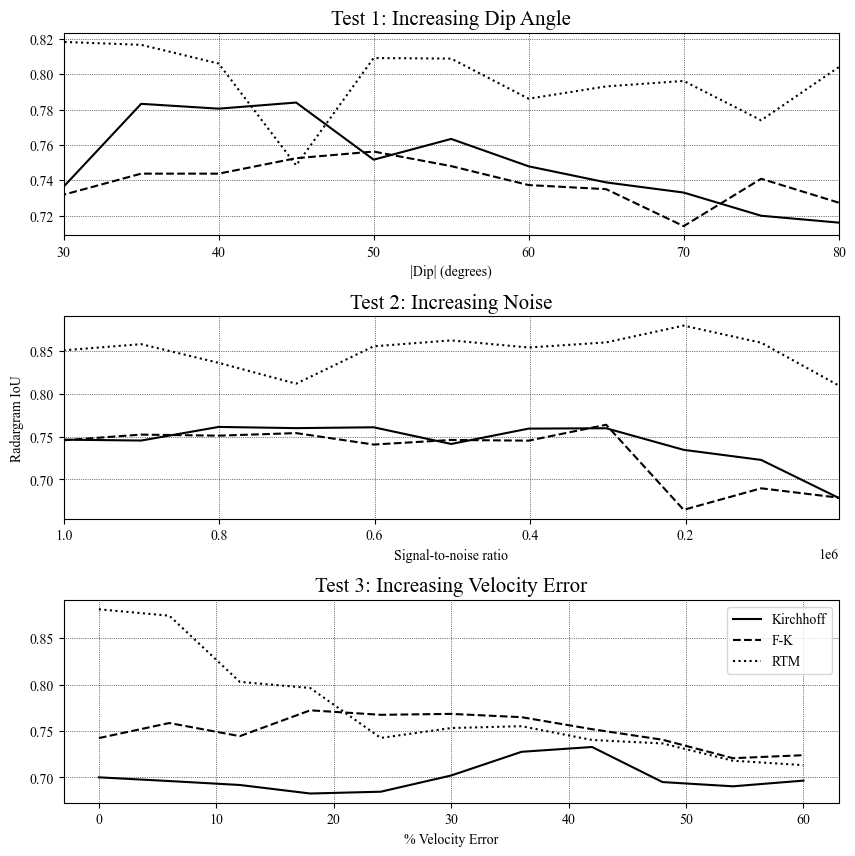

In [8]:
fig, axs = plt.subplots(3, figsize=(10, 10))

def norm(array):
    a = np.array(array)
    return a

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 10,
    'axes.titlesize': 15,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'black',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': True,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
})
    
dips = -(np.array([60, 55, 50, 45, 40, 35, 30, 25, 20, 15, 10])-90)
noises = np.linspace(3000, 1000000, 11)[::-1]

mags = np.linspace(0,60, 11) # 0,11

'''
Test 1
'''
axs[0].plot(dips[::-1], norm(data_iou_exp1[0::3]), label='Kirchhoff', c='black', linestyle='-', markersize=0)
axs[0].plot(dips[::-1], norm(data_iou_exp1[1::3]), label='F-K', c='black', linestyle='--', markersize=0)
axs[0].plot(dips[::-1], norm(data_iou_exp1[2::3]), label='RTM', c='black', linestyle=':', markersize=0)

axs[0].set_title('Test 1: Increasing Dip Angle'), axs[0].set_xlabel('|Dip| (degrees)')
axs[0].set_xlim(30, 80)
'''
test 2
'''
a = norm(data_iou_exp2[2::3])
axs[1].plot(noises, norm(data_iou_exp2[0::3]), label='Kirchhoff', c='black', linestyle='-', markersize=0)
axs[1].plot(noises, norm(data_iou_exp2[1::3]), label='F-K', c='black', linestyle='--', markersize=0)
axs[1].plot(noises, a, label='RTM', c='black', linestyle=':', markersize=0)

axs[1].set_ylabel('Radargram IoU'), axs[1].set_xlabel('Signal-to-noise ratio'), axs[1].set_title('Test 2: Increasing Noise')
axs[1].set_xlim(1000000, 3000)
'''
Test 3
'''
axs[2].plot(mags, norm(data_iou_exp3[0::3]), label='Kirchhoff', c='black', linestyle='-', markersize=0)
axs[2].plot(mags, norm(data_iou_exp3[1::3]), label='F-K', c='black', linestyle='--', markersize=0)
axs[2].plot(mags, norm(data_iou_exp3[2::3]), label='RTM', c='black', linestyle=':', markersize=0)

axs[2].set_xlabel('% Velocity Error'), axs[2].set_title('Test 3: Increasing Velocity Error')
axs[2].legend()


## Reproducing the RMSE plots

In [6]:
radargram = radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998

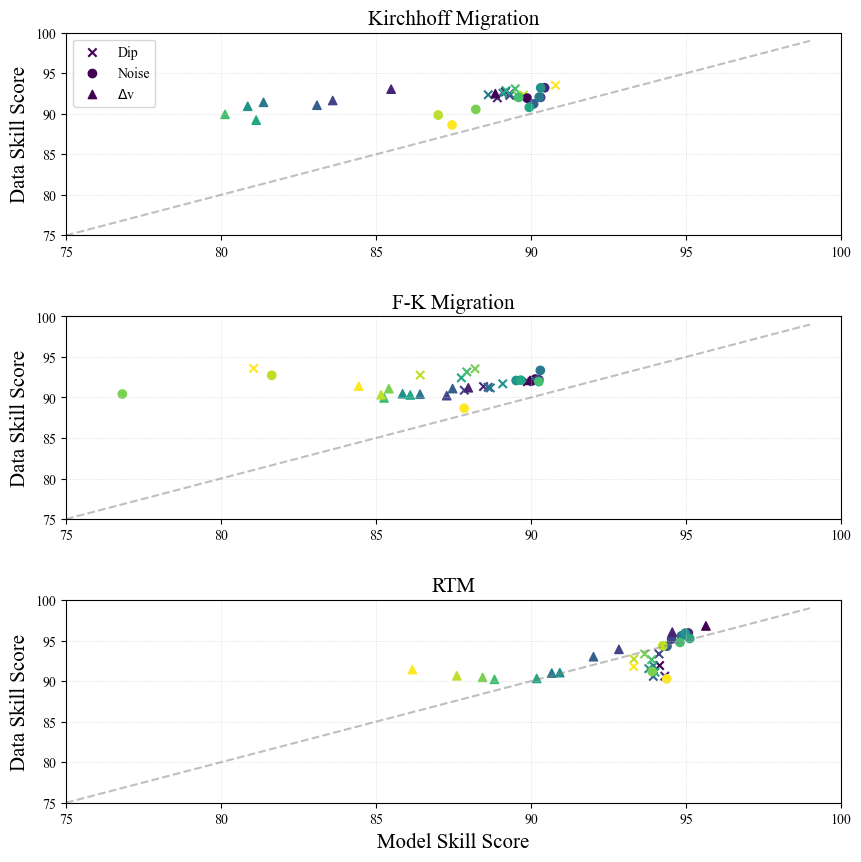

In [20]:
import random
fig, axs = plt.subplots(3, figsize=(10, 10))
def data_norm(array):
    a = np.array(array)
    RMSE_ref = np.sqrt(np.mean((radargram-np.mean(radargram))**2))
    a = 100*(1- a/(np.max(radargram)-np.min(radargram)))
    return a

def model_norm(array):
    a = np.array(array)
    RMSE_ref = np.sqrt(np.mean((eps-np.mean(eps))**2))
    a = 100*(1- a/(np.max(eps)-np.min(eps)))
    return a

def perturb_image(image, magnitude, seed):
    random.seed(seed)
    image_p = np.copy(image)
    for val in np.unique(image):
        image_p[np.where(image == val)] = val+(magnitude * random.choice([-1, 1]))
    return image_p
    
def model_norm_exp3(array):
    '''
    this needs to be a special function as the v_model reference actually changes
    '''
    eps_models = [perturb_image(eps, magnitude=mag, seed=1000) for mag in np.linspace(0,3,11)]

    a = []
    for i, val in enumerate(array):
        RMSE_ref = np.sqrt(np.mean((eps_models[i]-np.mean(eps_models[i]))**2))
        a.append(100*(1-(array[i]/(np.max(eps_models[i])-np.min(eps_models[i])))))
    return np.array(a)
    

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': True,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
})

'''
Kirchhoff
'''
l, h = 75, 100
axs[0].scatter(model_norm(velocity_RMSE_exp1[0::3]), data_norm(data_RMSE_exp1[0::3]), marker='x', label='Dip', c=range(0, len(data_RMSE_exp1[0::3])))
axs[0].scatter(model_norm(velocity_RMSE_exp2[0::3]), data_norm(data_RMSE_exp2[0::3]), marker='o', label='Noise', c=range(0, len(data_RMSE_exp2[0::3])))
axs[0].scatter(model_norm_exp3(velocity_RMSE_exp3[0::3]), data_norm(data_RMSE_exp3[0::3]), marker='^', label=f'$\Delta$v', c=range(0, len(data_RMSE_exp3[0::3])))
axs[0].set_title('Kirchhoff Migration'), axs[0].set_ylabel('Data Skill Score')
axs[0].set_xlim(l,h)
axs[0].set_ylim(l,h)
axs[0].plot(np.arange(l,h), np.arange(l,h), c='gray', linestyle='--', markersize=0, alpha=0.5)

axs[0].legend()
'''
F-K
'''
axs[1].scatter(model_norm(velocity_RMSE_exp1[1::3]), data_norm(data_RMSE_exp1[1::3]), marker='x', label='Dip', c=range(0, len(data_RMSE_exp1[1::3])))
axs[1].scatter(model_norm(velocity_RMSE_exp2[1::3]), data_norm(data_RMSE_exp2[1::3]), marker='o', label='Noise', c=range(0, len(data_RMSE_exp2[1::3])))
axs[1].scatter(model_norm_exp3(velocity_RMSE_exp3[1::3]), data_norm(data_RMSE_exp3[1::3]), marker='^', label=f'$\Delta$v', c=range(0, len(data_RMSE_exp3[1::3])))
axs[1].set_ylabel('Data Skill Score'), axs[1].set_title('F-K Migration')
axs[1].set_xlim(l,h)
axs[1].set_ylim(l,h)
axs[1].plot(np.arange(l,h), np.arange(l,h), c='gray', linestyle='--', markersize=0, alpha=0.5)
'''
RTM
'''
axs[2].scatter(model_norm(velocity_RMSE_exp1[2::3]), data_norm(data_RMSE_exp1[2::3]), marker='x', label='Dip', c=range(0, len(data_RMSE_exp1[2::3])))
axs[2].scatter(model_norm(velocity_RMSE_exp2[2::3]), data_norm(data_RMSE_exp2[2::3]), marker='o', label='Noise', c=range(0, len(data_RMSE_exp2[2::3])))
axs[2].scatter(model_norm_exp3(velocity_RMSE_exp3[2::3]), data_norm(data_RMSE_exp3[2::3]), marker='^', label=f'$\Delta$v', c=range(0, len(data_RMSE_exp3[2::3])))
axs[2].set_xlabel('Model Skill Score'), axs[2].set_title('RTM'), axs[2].set_ylabel('Data Skill Score')
axs[2].set_xlim(l,h)
axs[2].set_ylim(l,h)
axs[2].plot(np.arange(l,h), np.arange(l,h), c='gray', linestyle='--', markersize=0, alpha=0.5)

## AI disclosure
**only for code in this section**
| Cell # | How used |
|---|---|
| 1 | compute_consistency_metrics was written with AI. It threw in ssim and correlation coefficient metrics which is why the data contain these, I opt to not use these however as they don't use my in-house implementation, like IoU and RMSE which are fully described in the text. To be honest, if I were going back to do this again, I'd just use permetrics module|
|1|VelocityModelBuilder. App.py was generated with Anthropic's Claude, this is discussed at the start of the notebook|
